# ΔUHI & Built-environment
1. **Goal**: To investigate the possible relationship between SUHI response and built environment. Since we observed a significant increase in SUHI in several cities while others not, we are assuming that if this condition-dependence might be contributed to by composition of the built environment; we test whether this is true.

2. **Outcome Variable: Defining SUHI condition-dependence**: in this step, we define SUHI's condition-dependence as:
    
    *ΔUHI = UHI_extreme − UHI_baseline*

    - UHI_extreme: SUHI when the daily mean temperature is over 90 percentile of the daily mean temperature
    - UHI_baseline: the average of SUHI when the daily mean temperature is between 50-70 percentile.

    (Percentiles are computed within the warm-season window to ensure comparability across cities.)

3. **Explanatory Variables: Built-environment characteristics**:

    **Surface composition**:
      - Impervious surface fraction
      - Vegetation / NDVI / tree cover
      - Water or bare land fraction
      - LCZ composition

    **Urban form & intensity proxies**:
      - Built-up density / road density

4. **Analytical Strategy**
  - Analytical Unit: grid cell within each city (resolution =
  - Model:
  
    *ΔUHI_cell ~ composition_cell + proxies_cell + city fixed effects*

  - Comparison logic:
    - within-city: which built factors is correlated with ΔUHI_cell
    - across-city: does this explain why some city has higher ΔUHI
  
  - Control principles:
    - Same buffer scale
    - Same spatial resolution
    - Same seasonal window



In [1]:
!git init
!git remote add origin https://github.com/cchen744/uhi-extreme-heat-response.git
!git pull origin cell-delta-uhi
!git checkout cell-delta-uhi
!git status

!git config --global user.email cchen744@wisc.edu
!git config --global user.name cchen744

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
remote: Enumerating objects: 449, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 449 (delta 79), reused 25 (delta 20), pack-reused 322 (from 1)
Receiving objects: 100% (449/449), 10.74 MiB | 23.01 MiB/s, done.
Resolving deltas: 100% (245/245), done.
From https://github.com/cchen744/uhi-extreme-heat-response
 * branch            cell-delta-uhi -> FETCH_HEAD
 * [new branch]      cell-delta-u

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import shape
import ee
import uhi_pipeline
import importlib
import geemap
from pprint import pprint

ee.Authenticate()
ee.Initialize(project='extremeweatheruhi')

DATA_DIR = Path("data/city_cell")
DATA_DIR.mkdir(parents=True, exist_ok=True)

ua_fc = ee.FeatureCollection("projects/extremeweatheruhi/assets/uac20_2025")

In [4]:
importlib.reload(uhi_pipeline)
print("uhi_pipeline module reloaded.")

uhi_pipeline module reloaded.


Before starting analysis, we need to get daily output on the level of grid cell due to the need for intra-city built environment analysis. In uhi_pipeline.py, the grid cell is defined as a 1km x 1km square grid projected from EPSG: 3875.

In [5]:
city_fc=uhi_pipeline.select_ua(ua_fc,ua_contains="Phoenix")
city_geom = city_fc.geometry() # Get city boundary
urban_region = city_geom

Map = geemap.Map()
Map.addLayer(urban_region,{},'city')
Map.centerObject(urban_region, 10)
Map

Map(center=[33.497986517451864, -112.00262242282876], controls=(WidgetControl(options=['position', 'transparen…

In [ ]:
ic = (ee.ImageCollection("MODIS/061/MYD11A1") # Extract data: MODIS Aqua Land Surface Temperature daily product
      .filterBounds(city_geom) # filtered by Phoneix' boundary
      .filterDate("2019-07-01", "2019-07-08")) # filtered by a certain time window
print("IC count:", ic.size().getInfo()) # Check how many images of the city are there within the time frame

IC count: 7


In [ ]:
ic.first().bandNames().getInfo() # Print all bands in this one MODIS product

['LST_Day_1km',
 'QC_Day',
 'Day_view_time',
 'Day_view_angle',
 'LST_Night_1km',
 'QC_Night',
 'Night_view_time',
 'Night_view_angle',
 'Emis_31',
 'Emis_32',
 'Clear_day_cov',
 'Clear_night_cov']

In [6]:
 # extract local time zone and select LCZ_Filter for built-environment analysis
lcz_img = ee.ImageCollection("RUB/RUBCLIM/LCZ/global_lcz_map/latest").first()
lcz = lcz_img.select("LCZ_Filter")

# land surface temp relevant
lst_scale_m = 1000 # modis lst resolution / sampling scale for reduceRegions()
lst_band="LST_Night_1km"
qc_band="QC_Night"

# aggregation and spatial unit parameters
agg_func="median"
unit="cell"
cell_scale_m=4000 # grid size
cell_crs="EPSG:3857"
tileScale = 1 # the bigger, the more granuality it has

# time window
start_date="2016-06-01"
end_date="2019-08-31"

# define LCZ classification rule
BUILT_MIN, BUILT_MAX = 1, 10
WATER_CODE = 17

is_built = lcz.gte(BUILT_MIN).And(lcz.lte(BUILT_MAX))
is_water = lcz.eq(WATER_CODE)
is_natural = is_built.Not().And(is_water.Not())

# define urban region and urban reference region
ring_outer_m= 12000 # buffer ring from urban area (far)
ring_inner_m= 3000 # buffer ring from urban area (near)
outer = city_geom.buffer(ring_outer_m)
inner = city_geom.buffer(ring_inner_m)
rural_region = outer.difference(inner) # rural region is defined as area 3 km to 12 km from the city boundary

urban_mask = is_built.clip(urban_region)
rural_mask = is_natural.clip(rural_region)

In [ ]:
# Beneath the urban mask I have defined, does this image contain a sufficient number of valid LST pixels for use?
ic.first().clip(urban_region).reduceRegion(reducer=ee.Reducer.count(),
            geometry=urban_region,
            scale=lst_scale_m, # lst_scale_m = 1000
            maxPixels=1e13)

In [6]:
# time window
start_date="2022-06-01"
end_date="2022-06-02"

test_fc = uhi_pipeline.make_daily_table_cells(
    start_date, end_date,
    urban_region, rural_region,
    lst_band, qc_band,
    lst_scale_m=1000,
    cell_scale_m=4000,
    crs="EPSG:3857",
    err_m=100,
    tileScale=1)

In [7]:
# generate cell_id geometry lookup table
cell_id_gdf = geemap.ee_to_gdf(test_fc).to_crs(cell_crs)

print("cell geometry lookup table columns:", cell_id_gdf.columns)
print("cell geometry lookup table size:", len(cell_id_gdf))
print(cell_id_gdf.head())

cell geometry lookup table columns: Index(['geometry', 'LST_rur', 'LST_urb_cell', 'cell_id', 'date',
       'rural_cell_n', 'uhi', 'urb_cell_n'],
      dtype='object')
cell geometry lookup table size: 423
                                            geometry    LST_rur  LST_urb_cell  \
0  POLYGON ((-12412000 3920000, -12408000 3920000...  18.537716     17.228981   
1  POLYGON ((-12412000 3944000, -12408000 3944000...  18.537716     18.431457   
2  POLYGON ((-12412000 3948000, -12408000 3948000...  18.537716     19.044388   
3  POLYGON ((-12412000 3952000, -12408000 3952000...  18.537716     19.278502   
4  POLYGON ((-12416000 3912000, -12412000 3912000...  18.537716     18.341816   

        cell_id        date  rural_cell_n       uhi  urb_cell_n  
0 -310199999020  2022-06-01          3717 -1.308736           4  
1 -310199999014  2022-06-01          3717 -0.106259           5  
2 -310199999013  2022-06-01          3717  0.506672          19  
3 -310199999012  2022-06-01          3717  0

In [ ]:
non_empty_first = test_fc.filter(ee.Filter.gt("urb_cell_n", 0))
print("Properties:", non_empty_first.first().getInfo())

Properties: {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-111.82228656719803, 33.21592806426514], [-111.78635395583326, 33.21592806426514], [-111.78635395583326, 33.24598455571292], [-111.82228656719803, 33.24598455571292], [-111.82228656719803, 33.21592806426514]]]}, 'id': '0_-3112+981', 'properties': {'LST_rur': 26.219619238476955, 'LST_urb_cell': 27.00349565217392, 'cell_id': -311099999019, 'date': '2019-07-12', 'rural_cell_n': 265, 'system:time_start': 1562889600000, 'uhi': 0.7838764136969658, 'urb_cell_n': 7}}


In [ ]:
print("total:", test_fc.size().getInfo())
print("after filterDate:", test_fc.filter(ee.Filter.gt("urb_cell_n", 0)).size().getInfo())

total: 2961
after filterDate: 1931


In [ ]:
# 2019-07-14 experienced extreme heat so I am using it as a test sample.
one_day_fc = test_fc.filter(ee.Filter.eq("date", "2016-07-14"))
print("all cells: ", one_day_fc.size().getInfo())
print("valid cells: ", one_day_fc.filter(ee.Filter.gt("urb_cell_n",0)).size().getInfo())
print(one_day_fc.filter(ee.Filter.gt("urb_cell_n",0)).limit(5).getInfo())

# Visualization
uhi_img = one_day_fc.reduceToImage(
    properties=['uhi'],
    reducer=ee.Reducer.first()
)

vis = {
    'min': -5,
    'max': 5,
    'palette': ['blue', 'white', 'red']
}

Map = geemap.Map()
Map.centerObject(urban_region, 9)
Map.addLayer(uhi_img, vis, 'UHI 2016-07-14')
Map

all cells:  423
valid cells:  41
{'type': 'FeatureCollection', 'columns': {}, 'features': [{'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-111.82228656719803, 33.18586124525484], [-111.78635395583326, 33.18586124525484], [-111.78635395583326, 33.21592806426514], [-111.82228656719803, 33.21592806426514], [-111.82228656719803, 33.18586124525484]]]}, 'id': '2_-3112+980', 'properties': {'LST_rur': 29.171156080686224, 'LST_urb_cell': 29.038205128205163, 'cell_id': -311099999020, 'cell_n': 4, 'date': '2019-07-14', 'rural_n': 1414, 'uhi': -0.13295095248106037}}, {'type': 'Feature', 'geometry': {'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-111.82228656719803, 33.21592806426514], [-111.78635395583326, 33.21592806426514], [-111.78635395583326, 33.24598455571292], [-111.82228656719803, 33.24598455571292], [-111.82228656719803, 33.21592806426514]]]}, 'id': '2_-3112+981', 'properties': {'LST_rur': 29.171156080686224, 'LST_urb_cell': 27.135345413

Map(center=[33.497986517451864, -112.00262242282876], controls=(WidgetControl(options=['position', 'transparen…

### officially start exporting data

In [8]:
# time window
start_date="2025-06-01"
end_date="2025-09-01"

# Exporting one-week data
export_fc = uhi_pipeline.make_daily_table_cells(
    start_date, end_date,
    urban_region, rural_region,
    lst_band, qc_band,
    lst_scale_m=1000,
    cell_scale_m=4000,
    crs="EPSG:3857",
    err_m=100,
    tileScale=1)

# The first feature has null LST_urb and uhi. So we use selectors to fix the output column names.
task = ee.batch.Export.table.toDrive(
    collection=export_fc,
    description=f'phoenix_daily_cell_uhi_{start_date[:7]}_{end_date[:7]}',
    fileFormat='CSV',
    folder = "UHI/cell_level/phoenix",
    selectors=[
        'date',
        'cell_id',
        'LST_urb_cell',
        'urb_cell_n',
        'LST_rur',
        'rural_cell_n',
        'uhi',
        'system:time_start'
    ]
)
task.start()

print("Export started.")

Export started.


Check task status: https://code.earthengine.google.com/tasks

### phased analysis

In [7]:
# read three datasets
DATA_DIR = "/content/drive/MyDrive/UHI/cell_level/phoenix"

## city level uhi
city_df = pd.read_csv(DATA_DIR + "/phoenix_daily_suhi_2020_2025.csv")

## cell level uhi
cell_df_2020 = pd.read_csv(DATA_DIR + "/phoenix_daily_cell_uhi_2020-06_2020-09.csv")
cell_df_2021 = pd.read_csv(DATA_DIR + "/phoenix_daily_cell_uhi_2021-06_2021-09.csv")
cell_df_2022 = pd.read_csv(DATA_DIR + "/phoenix_daily_cell_uhi_2022-06_2022-09.csv")
cell_df_2023 = pd.read_csv(DATA_DIR + "/phoenix_daily_cell_uhi_2023-06_2023-09.csv")
cell_df_2024 = pd.read_csv(DATA_DIR + "/phoenix_daily_cell_uhi_2024-06_2024-09.csv")
cell_df_2025 = pd.read_csv(DATA_DIR + "/phoenix_daily_cell_uhi_2025-06_2025-09.csv")

## geometry lookup table
cell_id_gdf = gpd.read_file(DATA_DIR + "/phoenix_cell_id_gdf.geojson")

In [8]:
print("City df:\n",city_df.head(1))
print("\nCell df:\n",cell_df_2020.head(1))
print("\nCell id gdf:\n",cell_id_gdf.head(1))

City df:
      LST_rur    LST_urb        date  rural_n  urban_n      SUHI  is_extreme
0  21.527371  23.709812  2020-06-01     3320     3724  2.182442           0

Cell df:
          date       cell_id  LST_urb_cell  urb_cell_n    LST_rur  \
0  2020-06-01 -310199999020         21.23           3  21.570039   

   rural_cell_n       uhi  system:time_start  
0          3320 -0.340039      1590969600000  

Cell id gdf:
      LST_rur  LST_urb_cell       cell_id       date  rural_cell_n       uhi  \
0  18.537716     17.228981 -310199999020 2022-06-01          3717 -1.308736   

   urb_cell_n                                           geometry  
0           4  POLYGON ((-12412000 3920000, -12408000 3920000...  


#### Sample description:
- Time range, number of days
- number of extreme/baseline values
- number of cells

In [9]:
print("City: Phoenix, AZ")
print("Time window: 2020-06-01 to 2025-09-01")
print("Total days:", cell_df_2020['date'].nunique()*6)
print("Extreme days:", len(city_df[city_df['is_extreme']==1]))
print("Baseline days:", len(city_df[city_df['is_extreme']==0]))
print("Total cells:", len(cell_id_gdf))

City: Phoenix, AZ
Time window: 2020-06-01 to 2025-09-01
Total days: 546
Extreme days: 181
Baseline days: 1621
Total cells: 423


### City-level Visualizaiton
- Urban Land Surface Temperature
- Time series visualization for SUHI

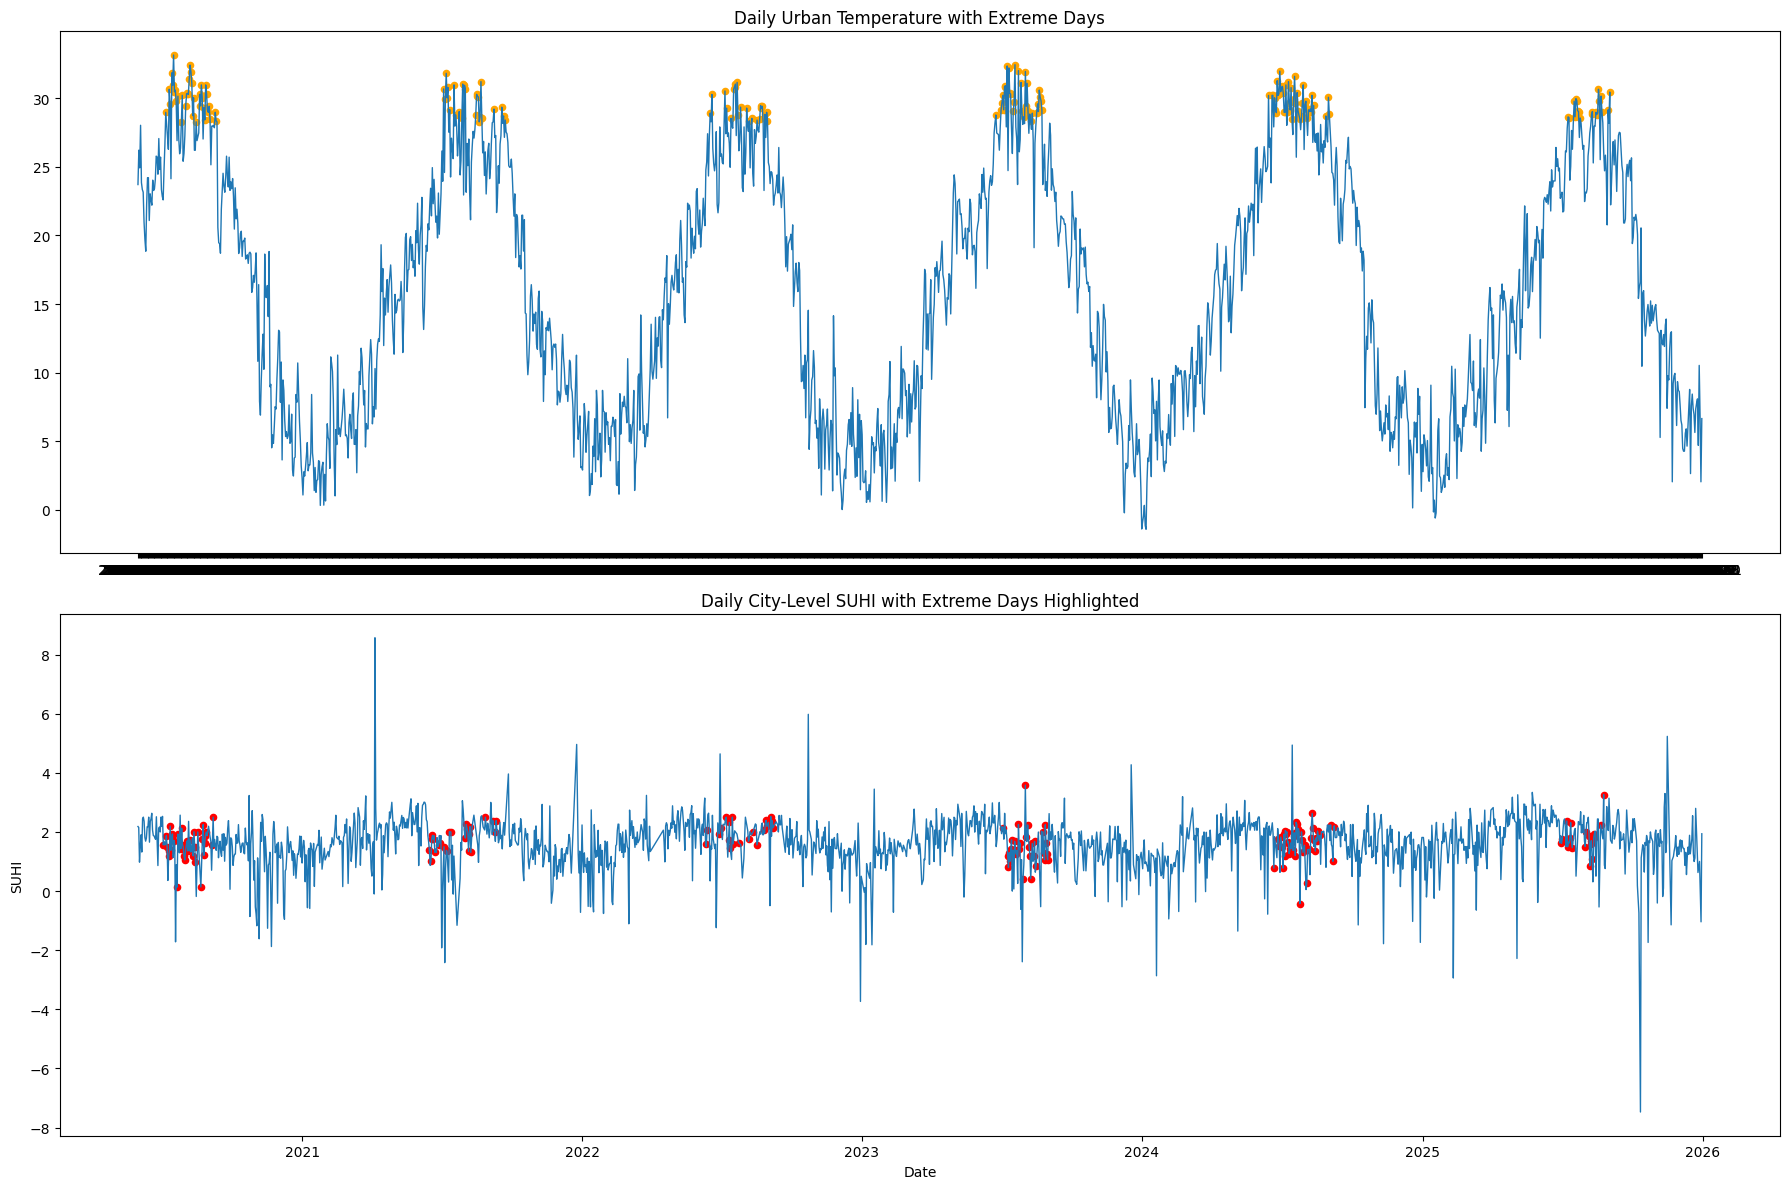

In [10]:
fig,ax = plt.subplots(2,1,figsize=(18,12))

ax[0].plot(city_df["date"], city_df["LST_urb"], linewidth=1)

extreme_df = city_df[city_df["is_extreme"] == 1]
ax[0].scatter(extreme_df["date"], extreme_df["LST_urb"], s=20,c='orange')

ax[0].set_title("Daily Urban Temperature with Extreme Days")


city_df["date"] = pd.to_datetime(city_df["date"], errors="coerce")
city_df = city_df.sort_values("date").copy()

# split
extreme_df = city_df[city_df["is_extreme"] == 1]
normal_df  = city_df[city_df["is_extreme"] == 0]


# main line
ax[1].plot(city_df["date"], city_df["SUHI"], linewidth=1)

# highlight extreme days
ax[1].scatter(extreme_df["date"], extreme_df["SUHI"], s=20,c='red')

ax[1].set_xlabel("Date")
ax[1].set_ylabel("SUHI")
ax[1].set_title("Daily City-Level SUHI with Extreme Days Highlighted")
fig.tight_layout() # Call tight_layout on the figure object

plt.show()

- SUHI vs. Extreme

Mann–Whitney test u, p: 147151.0 0.4729820649338966
Average difference in UHI: 0.07756970460906443
Correlation between LST_urb and SUHI:
           LST_urb      SUHI
LST_urb  1.000000  0.237559
SUHI     0.237559  1.000000


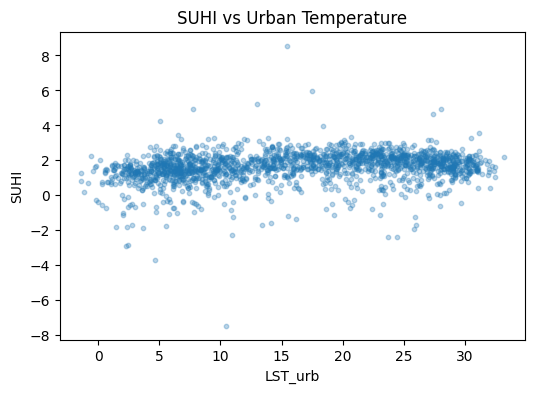

In [57]:
from scipy.stats import mannwhitneyu

mean_extreme = city_df.loc[city_df["is_extreme"] == 1, "SUHI"].mean()
mean_base    = city_df.loc[city_df["is_extreme"] == 0, "SUHI"].mean()

delta = mean_extreme - mean_base
suhi_non = city_df.loc[city_df["is_extreme"] == 0, "SUHI"]
suhi_ext = city_df.loc[city_df["is_extreme"] == 1, "SUHI"]

# Mann–Whitney test: check statistical significance
u, p = mannwhitneyu(
    suhi_ext,
    suhi_non,
    alternative="greater"
)

print("Mann–Whitney test u, p:", float(u), float(p))
print("Average difference in UHI:", delta)
print("Correlation between LST_urb and SUHI:\n", city_df[["LST_urb", "SUHI"]].corr())

# visualization
plt.figure(figsize=(6,4))
plt.scatter(city_df["LST_urb"], city_df["SUHI"], s=10, alpha=0.3)

plt.xlabel("LST_urb")
plt.ylabel("SUHI")
plt.title("SUHI vs Urban Temperature")
plt.show()

In [13]:
city_df["temp_bin"] = pd.qcut(city_df["LST_urb"], 5)

check = city_df.groupby("temp_bin").agg(
    mean_suhi=("SUHI", "mean"),
    count=("SUHI", "count")
)

print(check)

                              mean_suhi  count
temp_bin                                      
(-1.4109999999999998, 6.588]   1.209913    361
(6.588, 12.278]                1.439191    360
(12.278, 19.606]               1.818721    360
(19.606, 25.64]                1.868689    360
(25.64, 33.146]                1.716531    361


In [14]:
city_df["temp_bin_8"] = pd.qcut(city_df["LST_urb"], 8)


check = city_df.groupby("temp_bin_8").agg(
    mean_suhi=("SUHI", "mean"),
    count=("SUHI", "count")
)

print(check)

                             mean_suhi  count
temp_bin_8                                   
(-1.4109999999999998, 5.09]   1.097446    226
(5.09, 7.649]                 1.412656    225
(7.649, 11.235]               1.413828    225
(11.235, 16.025]              1.743769    225
(16.025, 20.53]               1.889240    225
(20.53, 24.15]                1.854252    225
(24.15, 27.702]               1.793148    225
(27.702, 33.146]              1.681188    226


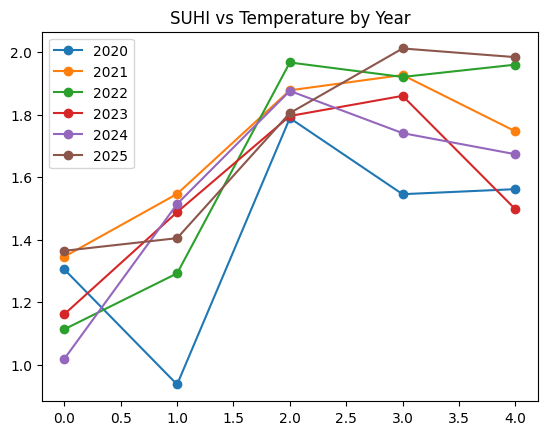

In [15]:
for year, df_y in city_df.groupby(city_df["date"].dt.year):
    df_y = df_y.copy()
    df_y["bin"] = pd.qcut(df_y["LST_urb"], 5)

    means = df_y.groupby("bin")["SUHI"].mean()

    plt.plot(range(len(means)), means.values, marker='o', label=str(year))

plt.legend()
plt.title("SUHI vs Temperature by Year")
plt.show()

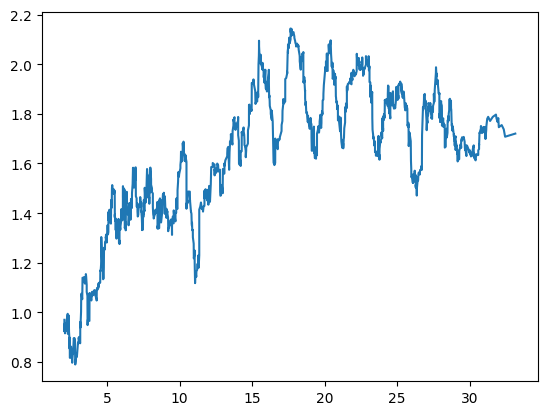

In [16]:
df_sorted = city_df.sort_values("LST_urb")

df_sorted["SUHI_smooth"] = df_sorted["SUHI"].rolling(50).mean()

plt.plot(df_sorted["LST_urb"], df_sorted["SUHI_smooth"])

A non-linear pattern of uhi is deduced from the graph above.

## Cell level visualization

In [20]:
# merge cell with city-level datasets
cell_df = pd.concat([cell_df_2020, cell_df_2021, cell_df_2022, cell_df_2023, cell_df_2024, cell_df_2025])
cell_df["date"] = pd.to_datetime(cell_df["date"], errors="coerce") # Convert 'date' column to datetime
cell_df = cell_df.merge(
    city_df[["date", "is_extreme"]],
    on="date",
    how="left"
)

In [23]:
print(cell_df.columns)
print(cell_df.size)
print(cell_df["is_extreme"].isna().sum())
cell_df_cleaned = cell_df.dropna(subset=["is_extreme"])

Index(['date', 'cell_id', 'LST_urb_cell', 'urb_cell_n', 'LST_rur',
       'rural_cell_n', 'uhi', 'system:time_start', 'is_extreme'],
      dtype='object')
2097657
27918


In [40]:
# group aggregation to get uhi under each temp situation
grouped = cell_df_cleaned.groupby(["cell_id", "is_extreme"])["uhi"].mean().unstack()
grouped["delta_uhi"] = grouped[1] - grouped[0]
grouped_gdf = gpd.GeoDataFrame(grouped.merge(cell_id_gdf, left_index=True, right_on="cell_id"))

print(grouped_gdf.columns)
print(grouped_gdf.size)
display(grouped_gdf.head())

Index([           0.0,            1.0,    'delta_uhi',      'LST_rur',
       'LST_urb_cell',      'cell_id',         'date', 'rural_cell_n',
                'uhi',   'urb_cell_n',     'geometry'],
      dtype='object')
4653


,0.0,1.0,delta_uhi,LST_rur,LST_urb_cell,cell_id,date,rural_cell_n,uhi,urb_cell_n,geometry
421,-0.162847,0.267391,0.430238,18.537716,17.712229,-313299999013,2022-06-01,3717,-0.825487,9,"POLYGON ((-12536000 3948000, -12532000 3948000..."
422,0.714004,1.076669,0.362665,18.537716,19.116971,-313299999012,2022-06-01,3717,0.579254,9,"POLYGON ((-12536000 3952000, -12532000 3952000..."
419,0.159504,0.527204,0.367701,18.537716,18.014615,-313199999013,2022-06-01,3717,-0.523101,9,"POLYGON ((-12532000 3948000, -12528000 3948000..."
420,1.211834,1.371793,0.159958,18.537716,19.517676,-313199999012,2022-06-01,3717,0.979960,15,"POLYGON ((-12532000 3952000, -12528000 3952000..."
415,0.028487,0.318183,0.289696,18.537716,17.313519,-313099999013,2022-06-01,3717,-1.224197,10,"POLYGON ((-12528000 3948000, -12524000 3948000..."


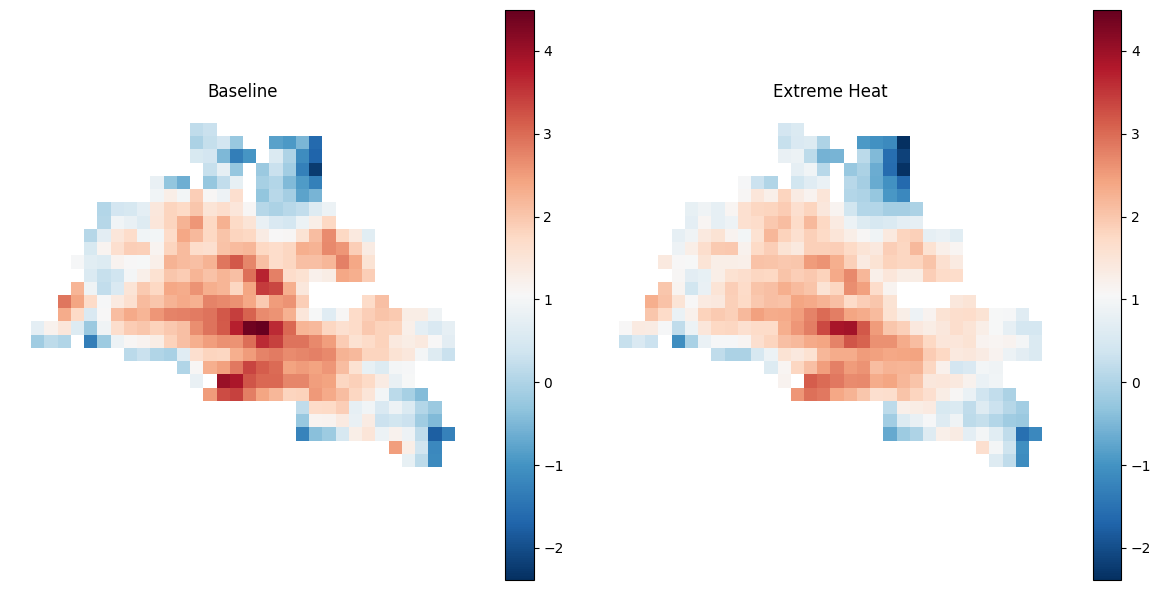

In [48]:
vmin = min(grouped_gdf[0.0].min(), grouped_gdf[1.0].min())
vmax = max(grouped_gdf[0.0].max(), grouped_gdf[1.0].max())

fig,ax = plt.subplots(1,2,figsize=(12,6))

ax[0] = grouped_gdf.plot(
    column = 0.0,
    cmap="RdBu_r",
    legend=True,
    edgecolor='none',
    vmin=vmin,
    vmax=vmax,
    ax=ax[0])
ax[0].set_title('Baseline')
ax[0].set_axis_off()

ax[1] = grouped_gdf.plot(
    column = 1.0,
    cmap="RdBu_r",
    legend=True,
    edgecolor='none',
    vmin=vmin,
    vmax=vmax,
    ax=ax[1])
ax[1].set_title('Extreme Heat')
ax[1].set_axis_off()

fig.tight_layout()

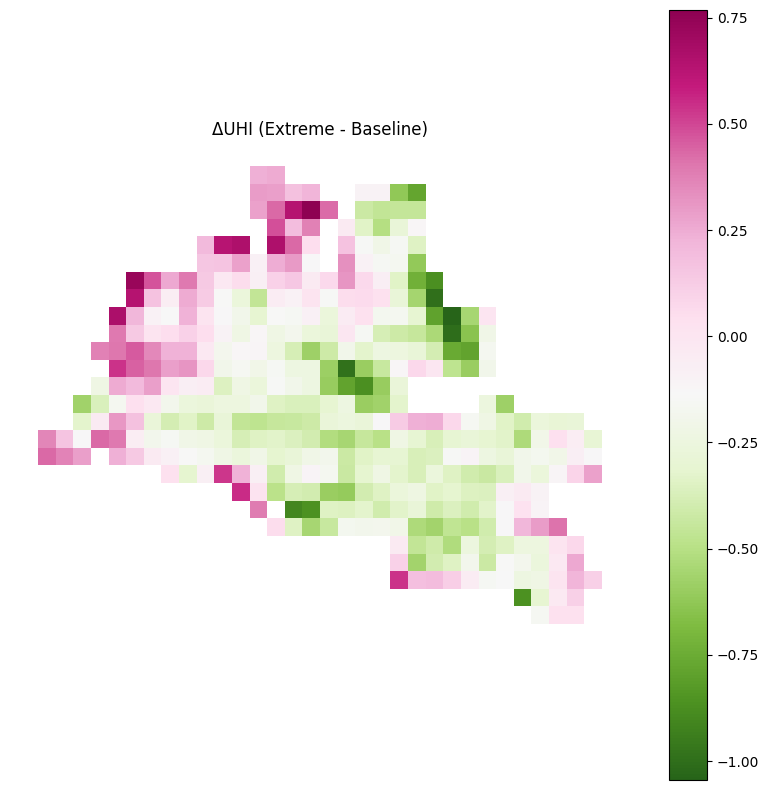

In [53]:
import numpy as np

gdf_map = grouped_gdf.copy()

# transform big interger
gdf_map["cell_id"] = gdf_map["cell_id"].astype(str)

# only keep necessary columns
gdf_plot = gdf_map[["delta_uhi", "geometry"]].dropna().copy()
gdf_plot = gdf_plot[gdf_plot.is_valid].copy()

ax = gdf_plot.plot(
    column="delta_uhi",
    cmap="PiYG_r",
    legend=True,
    figsize=(10, 10),
    edgecolor="none"
)

ax.set_title("ΔUHI (Extreme - Baseline)")
ax.set_axis_off()

In [54]:
 # Moran's I
from libpysal.weights import KNN
from esda.moran import Moran
w = KNN.from_dataframe(gdf_plot, k=8)
w.transform = 'r'


y = gdf_plot["delta_uhi"].values

mi = Moran(y, w)

print("Moran's I:", mi.I)
print("p-value:", mi.p_sim)

Moran's I: 0.6138906330310956
p-value: 0.001


In [ ]:
commit_msg = 'UPDATE: merged cell table generation logic with city table generation logic'
! git add uhi_pipeline.py
! git commit -m commit_msg
! git push --set-upstream origin main cell-delta-uhi